<a href="https://colab.research.google.com/github/AshutoshPant746/PatternRecognition/blob/gh-pages/pattern_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/dl lab/weatherAUS.csv")

# Print missing values in each column
print("Missing values before preprocessing:\n")
print(df.isnull().sum())



Missing values before preprocessing:

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64



Dropped columns: ['Evaporation', 'Sunshine']


<ipython-input-22-29cb65cb82d8>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
<ipython-input-22-29cb65cb82d8>:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_cols = df.select_dtypes(include=['object']).columns[df.select_dtypes(include=['object']).apply(lambda x: pd.to_datetime(x, errors='coerce').notna().all())]
<ipython-input-22-2


Missing values after encoding:
 0

Data types before training:
 Location             int64
MinTemp            float64
MaxTemp            float64
Rainfall           float64
WindGustDir          int64
WindGustSpeed      float64
WindDir9am           int64
WindDir3pm           int64
WindSpeed9am       float64
WindSpeed3pm       float64
Humidity9am        float64
Humidity3pm        float64
Pressure9am        float64
Pressure3pm        float64
Cloud9am           float64
Cloud3pm           float64
Temp9am            float64
Temp3pm            float64
RainToday            int64
RISK_MM            float64
RainTomorrow         int64
Date_year            int32
Date_month           int32
Date_day             int32
Date_weekday         int32
Date_days_since      int64
dtype: object

Training set shape: (113754, 25) (113754,)
Testing set shape: (28439, 25) (28439,)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model trained successfully!

Model Performance Metrics:
Accuracy: 0.9727
Precision: 0.9665
Recall: 0.9096
F1 Score: 0.9372
AUC-ROC Score: 0.9963


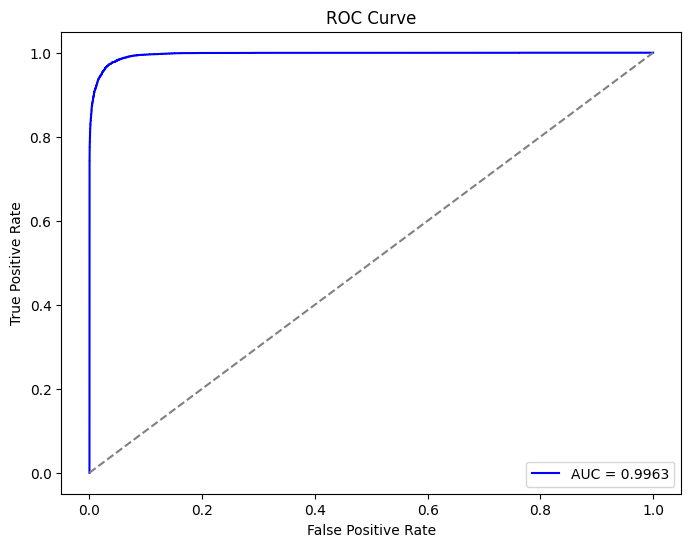


Prediction for sample data (0=No Rain, 1=Rain): 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [22]:
threshold =60000
columns_to_drop = df.columns[df.isnull().sum() > threshold]
df.drop(columns=columns_to_drop, inplace=True)

print("\nDropped columns:", columns_to_drop)



num_cols = df.select_dtypes(include=['float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Fill numerical columns with median
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

date_cols = df.select_dtypes(include=['object']).columns[df.select_dtypes(include=['object']).apply(lambda x: pd.to_datetime(x, errors='coerce').notna().all())]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
    df[f'{col}_weekday'] = df[col].dt.weekday
    df[f'{col}_days_since'] = (df[col] - df[col].min()).dt.days
    df.drop(columns=[col], inplace=True)

label_encoders = {}
for col in ['RainToday', 'RainTomorrow', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nMissing values after encoding:\n", df.isnull().sum().sum())


scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


print("\nData types before training:\n", df.dtypes)


X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("\nTraining set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

# Train Logistic Regression model
try:
    model = LogisticRegression(max_iter=1000, C=0.1)
    model.fit(X_train, y_train)
    print("\nModel trained successfully!")
except ValueError as e:
    print("\nError while training the model:", e)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability scores for ROC AUC


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC Score: {roc_auc:.4f}")


fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Predict on a new sample (example: first row from test set)
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)
print("\nPrediction for sample data (0=No Rain, 1=Rain):", prediction[0])


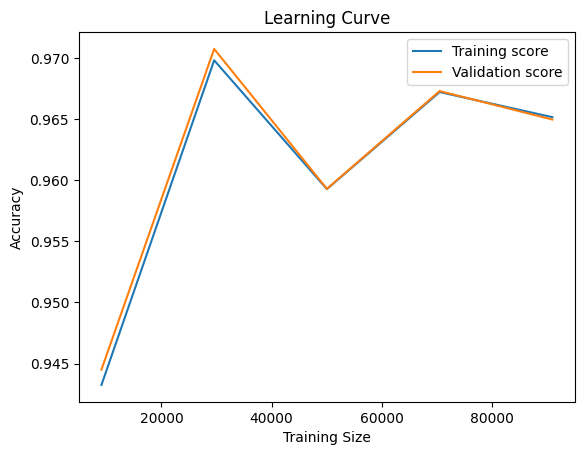

In [23]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Calculate mean and std for plot
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, validation_mean, label="Validation score")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
